## Importing libraries

In [1]:
import re
import time
from collections import Counter
from pathlib import Path

import matplotlib.pyplot as plt

## Levenshtein distance

In [2]:
def levenshtein_distance(s1: str, s2: str) -> int:
    """
    Standard Levenshtein distance using dynamic programming.
    Allowed operations:
      - insertion
      - deletion
      - substitution

    Returns the minimum number of edits needed to transform s1 into s2.
    """
    m, n = len(s1), len(s2)

    dp = [[0] * (n + 1) for _ in range(m + 1)]

    for i in range(m + 1):
        dp[i][0] = i
    for j in range(n + 1):
        dp[0][j] = j

    for i in range(1, m + 1):
        for j in range(1, n + 1):
            cost = 0 if s1[i - 1] == s2[j - 1] else 1
            dp[i][j] = min(
                dp[i - 1][j] + 1,        # deletion
                dp[i][j - 1] + 1,        # insertion
                dp[i - 1][j - 1] + cost  # substitution or match
            )

    return dp[m][n]


def levenshtein_table(s1: str, s2: str):
    """
    Returns the full DP table for visualization or explanation.
    """
    m, n = len(s1), len(s2)
    dp = [[0] * (n + 1) for _ in range(m + 1)]

    for i in range(m + 1):
        dp[i][0] = i
    for j in range(n + 1):
        dp[0][j] = j

    for i in range(1, m + 1):
        for j in range(1, n + 1):
            cost = 0 if s1[i - 1] == s2[j - 1] else 1
            dp[i][j] = min(
                dp[i - 1][j] + 1,
                dp[i][j - 1] + 1,
                dp[i - 1][j - 1] + cost
            )
    return dp


## Dictionary preparation

In [3]:
def tokenize(text: str):
    """
    Lowercase tokenization for English alphabetic words.
    """
    return re.findall(r"[a-z]+", text.lower())


def build_dictionary(text: str) -> Counter:
    """
    Build a frequency dictionary from text.
    """
    return Counter(tokenize(text))


SAMPLE_CORPUS = """
I will go to the restaurant tonight and order a delicious dessert before going home.
The restaurant is open tonight and serves delicious food.
I will order a dessert at the restaurant tonight.
People go to the restaurant for dinner and dessert.
We will go home before midnight.
I will eat a delicious meal and dessert.
The restaurant menu has soup, salad, pasta, rice, bread, tea, coffee, and cake.
Tonight we will order food before going home.
Good food and a delicious dessert make the restaurant popular.
"""


## Candidate generation (Norvig-style)

In [4]:
ALPHABET = "abcdefghijklmnopqrstuvwxyz"


def edits1(word: str, alphabet: str = ALPHABET):
    """
    Generate all unique candidates at edit distance 1 using:
      - deletion
      - adjacent swap
      - substitution
      - insertion
    """
    splits = [(word[:i], word[i:]) for i in range(len(word) + 1)]

    deletes = [L + R[1:] for L, R in splits if R]
    transposes = [L + R[1] + R[0] + R[2:] for L, R in splits if len(R) > 1]
    replaces = [L + c + R[1:] for L, R in splits if R for c in alphabet]
    inserts = [L + c + R for L, R in splits for c in alphabet]

    return set(deletes + transposes + replaces + inserts)


def edits2(word: str, alphabet: str = ALPHABET):
    """
    Generate all unique candidates at edit distance at most 2
    by applying edits1 to every edits1 candidate.
    """
    result = set()
    for e1 in edits1(word, alphabet):
        result.update(edits1(e1, alphabet))
    return result


def known(words, word_freq):
    """
    Keep only words that exist in the dictionary.
    """
    return {w for w in words if w in word_freq}


def correct_word_candidate_generation(word: str, word_freq, alphabet: str = ALPHABET):
    """
    Choose the most probable correction:
      1) word itself if known
      2) best known edit-distance-1 candidate
      3) best known edit-distance-2 candidate
      4) otherwise the original word
    """
    if word in word_freq:
        return word

    c1 = known(edits1(word, alphabet), word_freq)
    if c1:
        return max(c1, key=lambda w: word_freq[w])

    c2 = known(edits2(word, alphabet), word_freq)
    if c2:
        return max(c2, key=lambda w: word_freq[w])

    return word


def correct_sentence(sentence: str, word_freq, alphabet: str = ALPHABET):
    """
    Correct each word in a sentence independently.
    """
    tokens = re.findall(r"[A-Za-z']+|[.,!?;]", sentence)
    corrected = []

    for token in tokens:
        if re.fullmatch(r"[A-Za-z']+", token):
            corrected.append(correct_word_candidate_generation(token.lower(), word_freq, alphabet))
        else:
            corrected.append(token)

    parts = []
    for i, token in enumerate(corrected):
        if i > 0 and token not in ".,!?;":
            parts.append(" ")
        parts.append(token)
    return "".join(parts)



## Brute-force approach

In [6]:
def brute_force_correct(word: str, word_freq):
    """
    Compare the input word to every dictionary word using Levenshtein distance.
    Choose:
      - smallest edit distance
      - break ties by higher frequency
    """
    best_word = word
    best_distance = float("inf")
    best_frequency = -1

    for candidate in word_freq:
        dist = levenshtein_distance(word, candidate)

        if dist < best_distance:
            best_distance = dist
            best_word = candidate
            best_frequency = word_freq[candidate]
        elif dist == best_distance and word_freq[candidate] > best_frequency:
            best_word = candidate
            best_frequency = word_freq[candidate]

    return best_word, best_distance


## Experiments

In [42]:
def run_levenshtein_tests():
    print("=" * 70)
    print("LEVENSHTEIN DISTANCE TESTS")
    print("=" * 70)

    test_pairs = [
        ("cat", "cat"),
        ("cat", "cut"),
        ("cat", "cats"),
        ("kitten", "sitting"),
        ("restorant", "restaurant"),
        ("restorant", "restoring"),
        ("tonigth", "tonight"),
        ("befor", "before"),
    ]

    for a, b in test_pairs:
        d = levenshtein_distance(a, b)
        print(f"{a:12s} -> {b:12s} : distance = {d}")


def run_correction_demo(word_freq):
    print("\n" + "=" * 70)
    print("SPELLING CORRECTION DEMO")
    print("=" * 70)

    # sentence = "The Priem Minstere has denied he new AWB was playing kickbacks to Irqa despite writiing to the whet exporter asking to be kept fuly inform on Iraq wheat sales."
    sentence = "I well go to the restorant tonigth and order a delicshus desert befor going home."
    corrected = correct_sentence(sentence, word_freq)

    print("Original sentence:")
    print(sentence)
    print("\nCorrected sentence (candidate generation):")
    print(corrected)

    print()
    print('restoring:', word_freq['restoring'])
    print('restaurant:', word_freq['restaurant'])


def run_method_comparison(word_freq):
    print("\n" + "=" * 70)
    print("METHOD COMPARISON")
    print("=" * 70)

    test_words = ["well", "restorant", "tonigth", "delicshus", "befor", "restarant", "desert"]

    rows = []
    for word in test_words:
        t0 = time.perf_counter()
        corr1 = correct_word_candidate_generation(word, word_freq)
        t1 = time.perf_counter() - t0

        t0 = time.perf_counter()
        corr2, dist2 = brute_force_correct(word, word_freq)
        t2 = time.perf_counter() - t0

        rows.append((word, corr1, t1, corr2, dist2, t2))

    print(f"{'word':12s} | {'candidate-gen':15s} | {'time(s)':10s} | {'brute-force':15s} | {'dist':4s} | {'time(s)':10s}")
    print("-" * 90)
    for word, corr1, t1, corr2, dist2, t2 in rows:
        print(f"{word:12s} | {corr1:15s} | {t1:10.6f} | {corr2:15s} | {dist2:<4d} | {t2:10.6f}")

    return rows



## Visualizations

In [43]:
def plot_candidate_counts(output_dir: Path):
    """
    Plot how candidate counts explode from edit distance 1 to 2.
    """
    words = ["cat", "home", "dinner", "restorant", "delicshus"]
    e1_counts = [len(edits1(w)) for w in words]
    e2_counts = [len(edits2(w)) for w in words]

    x = range(len(words))
    width = 0.38

    plt.figure(figsize=(10, 5))
    plt.bar([i - width / 2 for i in x], e1_counts, width=width, label="Edit distance 1")
    plt.bar([i + width / 2 for i in x], e2_counts, width=width, label="Edit distance 2")
    plt.xticks(list(x), words, rotation=20)
    plt.ylabel("Number of generated variants")
    plt.title("Candidate explosion as word length increases")
    plt.yscale("log") 
    plt.legend()
    plt.tight_layout()
    plt.show()
    # path = output_dir / "candidate_counts.png"
    # plt.savefig(path, dpi=150)
    # plt.close()
    # return path


def plot_runtime_comparison(rows, output_dir: Path):
    """
    Compare runtime of candidate generation and brute force for several words.
    """
    words = [r[0] for r in rows]
    candidate_times = [r[2] * 1000 for r in rows]  # ms
    brute_times = [r[5] * 1000 for r in rows]      # ms

    x = range(len(words))
    width = 0.38

    plt.figure(figsize=(10, 5))
    plt.bar([i - width / 2 for i in x], candidate_times, width=width, label="Candidate generation")
    plt.bar([i + width / 2 for i in x], brute_times, width=width, label="Brute-force dictionary search")
    plt.xticks(list(x), words, rotation=20)
    plt.ylabel("Runtime (ms)")
    plt.title("Runtime comparison of spelling correction methods")
    plt.legend()
    plt.tight_layout()
    plt.show()

    # path = output_dir / "runtime_comparison.png"
    # plt.savefig(path, dpi=150)
    # plt.close()
    # return path


def plot_distance_heatmap(output_dir: Path):
    """
    A simple DP-table heatmap to visualize how Levenshtein distance is computed.
    """
    s1 = "kitten"
    s2 = "sitting"
    dp = levenshtein_table(s1, s2)

    plt.figure(figsize=(8, 6))
    plt.imshow(dp, aspect="auto")
    plt.colorbar(label="Edit distance value")
    plt.title("Levenshtein DP table for 'kitten' -> 'sitting'")
    plt.xlabel("Prefix length of second word")
    plt.ylabel("Prefix length of first word")

    # annotate cells
    for i in range(len(dp)):
        for j in range(len(dp[0])):
            plt.text(j, i, str(dp[i][j]), ha="center", va="center", fontsize=8)

    plt.tight_layout()
    plt.show()


In [44]:
def load_text_file(path: str) -> str:
    with open(path, "r", encoding="utf-8") as f:
        return f.read()

Dictionary size: 31084
Most common words: [('the', 76960), ('of', 36525), ('to', 34245), ('and', 27879), ('in', 24573), ('a', 22649), ('is', 16130), ('that', 15378), ('for', 11347), ('it', 10104)]
LEVENSHTEIN DISTANCE TESTS
cat          -> cat          : distance = 0
cat          -> cut          : distance = 1
cat          -> cats         : distance = 1
kitten       -> sitting      : distance = 3
restorant    -> restaurant   : distance = 2
restorant    -> restoring    : distance = 2
tonigth      -> tonight      : distance = 2
befor        -> before       : distance = 1

SPELLING CORRECTION DEMO
Original sentence:
I well go to the restorant tonigth and order a delicshus desert befor going home.

Corrected sentence (candidate generation):
i well go to the restoring tonight and order a delicious desert before going home.

restoring: 18
restaurant: 10

METHOD COMPARISON
word         | candidate-gen   | time(s)    | brute-force     | dist | time(s)   
---------------------------------------

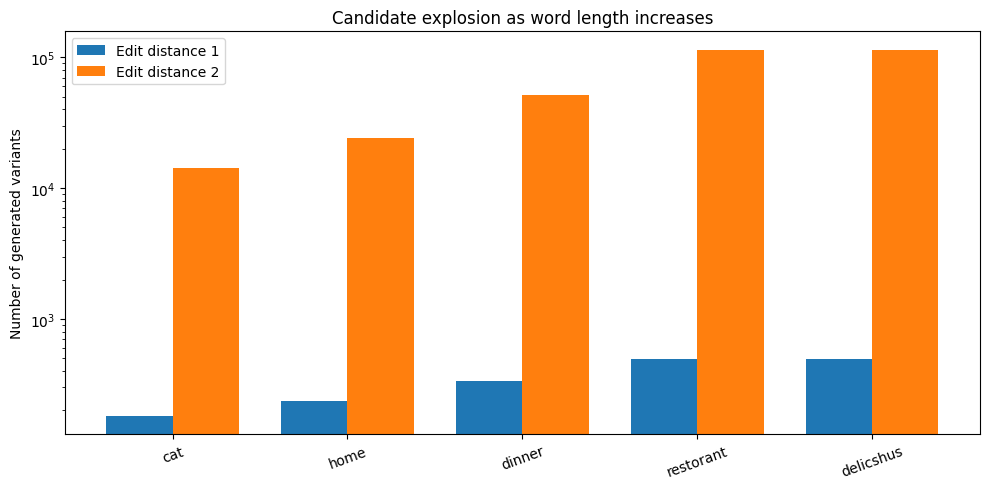

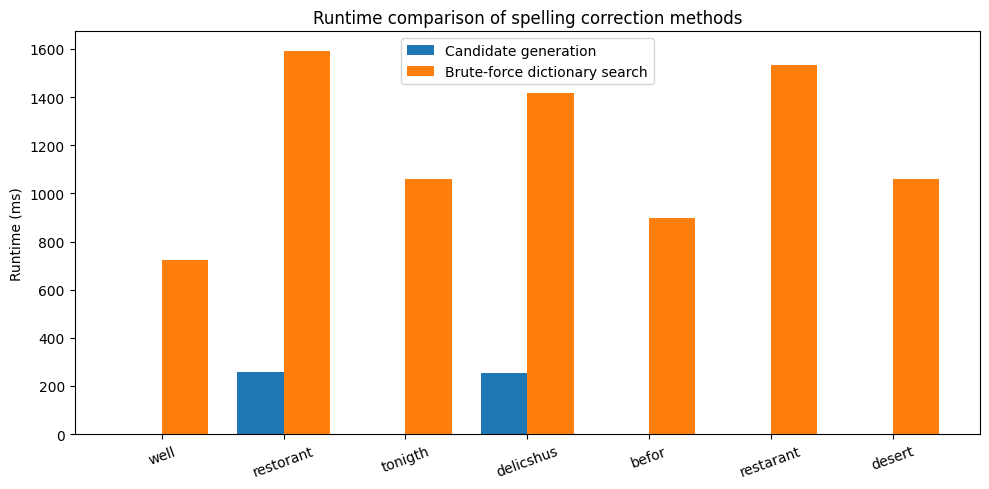

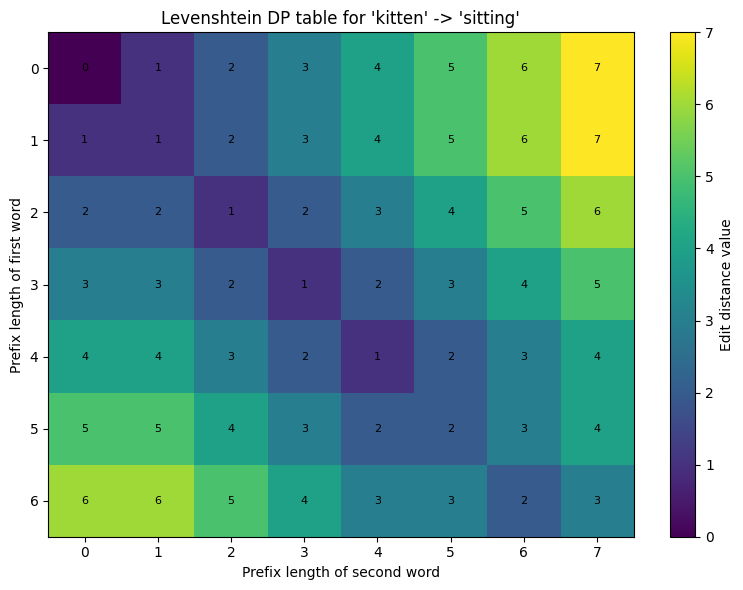

In [47]:
## Main

def main():
    output_dir = Path(".")
    corpus = corpus = load_text_file("./datasets/science.txt")
    word_freq = build_dictionary(corpus)

    print("Dictionary size:", len(word_freq))
    print("Most common words:", word_freq.most_common(10))

    run_levenshtein_tests()
    run_correction_demo(word_freq)
    rows = run_method_comparison(word_freq)

    plot_candidate_counts(output_dir)
    plot_runtime_comparison(rows, output_dir)
    plot_distance_heatmap(output_dir)

    # print("\n" + "=" * 70)
    # print("VISUALIZATION FILES SAVED")
    # print("=" * 70)
    # print(candidate_plot.resolve())
    # print(runtime_plot.resolve())
    # print(heatmap_plot.resolve())

    # print("\nINTERPRETATION NOTES")
    # print("- candidate_counts.png:")
    # print("  Edit distance 2 produces far more candidates than edit distance 1.")
    # print("  The longer the word, the faster the number of generated variants grows.")
    # print("  This explains why candidate generation can become expensive for long words.")

    # print("- runtime_comparison.png:")
    # print("  Candidate generation is often faster when the dictionary is larger,")
    # print("  because it avoids comparing the query with every dictionary word.")
    # print("  Brute force is simple but its cost grows with dictionary size.")

    # print("- distance_heatmap.png:")
    # print("  The DP table shows the cost of transforming prefixes of one word into prefixes")
    # print("  of the other. The bottom-right cell is the final Levenshtein distance.")


if __name__ == "__main__":
    main()
